<a href="https://colab.research.google.com/github/evanastevska/InternSift-ML/blob/master/imbalanced_text_classification_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install -q transformers datasets evaluate scikit-learn pandas torch

In [12]:
#preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("Cinema Verde Intern_Spam Dataset - Sheet1 (2).csv")

#concatenate Sender, Subject, and Email Text
df['Combined_Text'] = "Sender: " + df['Sender'].astype(str) + " | Subject: " + df['Subject'].astype(str) + " | Body: " + df['Email Text'].astype(str)

#extract new combined feature and labels
df = df[['Combined_Text', 'Label']].dropna()

#labels to integers
df['Label'] = df['Label'].map({'LEGIT': 0, 'SPAM': 1})

#stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['Combined_Text'],
    df['Label'],
    test_size=0.2,
    random_state=42,
    stratify=df['Label']
)

print(f"Training set size: {len(X_train)} (Spam: {sum(y_train)}, Legit: {len(y_train) - sum(y_train)})")
print(f"Testing set size: {len(X_test)} (Spam: {sum(y_test)}, Legit: {len(y_test) - sum(y_test)})")
#sample
print(f"\nSample Input to Model:\n{X_train.iloc[0][:150]}...")

Training set size: 120 (Spam: 40, Legit: 80)
Testing set size: 30 (Spam: 10, Legit: 20)

Sample Input to Model:
Sender: no-reply-forms@webflow.com | Subject: New Internship Form submission at Cinema Verde | Body: You just received a new Internship Form submissio...


In [13]:
#tokenization and dataset formatting
from transformers import AutoTokenizer
from datasets import Dataset

#DistilBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

#convert Pandas DataFrames to Hugging Face Dataset objects
train_df = pd.DataFrame({'text': X_train.values, 'label': y_train.values})
test_df = pd.DataFrame({'text': X_test.values, 'label': y_test.values})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

def tokenize_function(examples):
    #truncate emails to 256 tokens to keep training fast on free Colab GPU
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

#apply tokenization across the datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

#format for PyTorch
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])
tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

print("Tokenization complete. Datasets are formatted for PyTorch.")
print(f"Sample tokenized keys: {tokenized_train.features.keys()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Tokenization complete. Datasets are formatted for PyTorch.
Sample tokenized keys: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


In [14]:
#model and metrics
import numpy as np
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#load model for binary classification
#num_labels=2 matches classes (0: Legit, 1: Spam)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

#metrics for imbalanced minority class
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    #average='binary' focuses the scores on detecting the Spam class (# = 1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision, #how many of the predicted spams were actually spam
        'recall': recall #how many of the actual spams did we catch
    }

training_args = TrainingArguments(
    output_dir="./results_baseline",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

#Hugging Face Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Model and Trainer initialized. Ready to train.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model and Trainer initialized. Ready to train.


Starting Baseline Training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.545339,0.666667,0.000000,0.000000,0.000000
2,No log,0.441446,0.766667,0.461538,1.000000,0.300000
3,No log,0.417416,0.933333,0.909091,0.833333,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Evaluating on Test Set...


Baseline Test Metrics: {'eval_loss': 0.41741645336151123, 'eval_accuracy': 0.9333333333333333, 'eval_f1': 0.9090909090909091, 'eval_precision': 0.8333333333333334, 'eval_recall': 1.0, 'eval_runtime': 12.5127, 'eval_samples_per_second': 2.398, 'eval_steps_per_second': 0.32, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


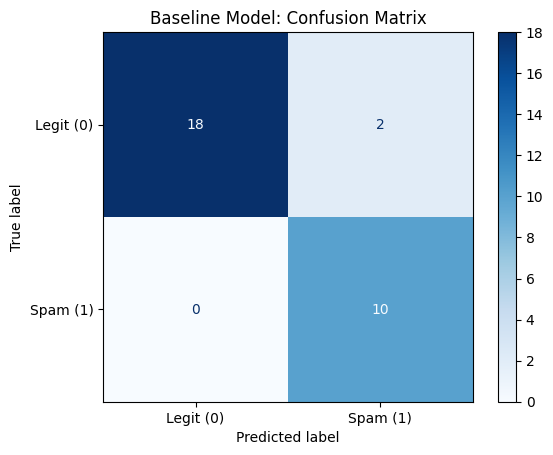

In [ ]:
#train Baseline + generate confusion matrix
print("Starting Baseline Training...")
trainer.train()

print("\nEvaluating on Test Set...")
eval_results = trainer.evaluate()
print(f"Baseline Test Metrics: {eval_results}")

#generate predictions for confusion matrix
predictions = trainer.predict(tokenized_test)
y_pred = predictions.predictions.argmax(-1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit (0)', 'Spam (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Baseline Model: Confusion Matrix")
plt.show()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Weighted Model...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.571447,0.800000,0.571429,1.000000,0.400000
2,No log,0.424141,0.900000,0.869565,0.769231,1.000000
3,No log,0.377817,0.866667,0.833333,0.714286,1.000000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Evaluating Weighted Model on Test Set...


Weighted Test Metrics: {'eval_loss': 0.3778165280818939, 'eval_accuracy': 0.8666666666666667, 'eval_f1': 0.8333333333333334, 'eval_precision': 0.7142857142857143, 'eval_recall': 1.0, 'eval_runtime': 12.6185, 'eval_samples_per_second': 2.377, 'eval_steps_per_second': 0.317, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


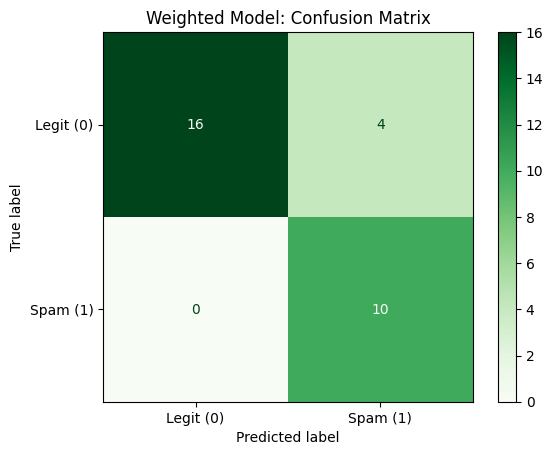

In [ ]:
#Weighted Training
import torch
from torch import nn

#reinitialize fresh blank model
weighted_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        #pass inputs through the model
        outputs = model(**inputs)
        logits = outputs.get("logits")

        #the fix: legit (# = 0) gets a weight of 1.0. Spam (# = 1) gets a weight of 2.0. (bc theres 100 legit and 50 spam)
        #model will now pay 2x more attention to minority Spamclass
        class_weights = torch.tensor([1.0, 2.0]).to(model.device)

        #grading rubric: apply the 2x penalty weight for missing the Spam clas
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)

        #flatten the arrays to 1D and calculate the final penalty by comparing guesses to actual answers
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

#set up new output directory for the weighted model
weighted_args = TrainingArguments(
    output_dir="./results_weighted",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

#weighted trainer
weighted_trainer = WeightedTrainer(
    model=weighted_model,
    args=weighted_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Training Weighted Model...")
weighted_trainer.train()

print("\nEvaluating Weighted Model on Test Set...")
weighted_results = weighted_trainer.evaluate()
print(f"Weighted Test Metrics: {weighted_results}")

predictions_w = weighted_trainer.predict(tokenized_test)
y_pred_w = predictions_w.predictions.argmax(-1)
y_true_w = predictions_w.label_ids

cm_w = confusion_matrix(y_true_w, y_pred_w)
disp_w = ConfusionMatrixDisplay(confusion_matrix=cm_w, display_labels=['Legit (0)', 'Spam (1)'])
disp_w.plot(cmap=plt.cm.Greens)
plt.title("Weighted Model: Confusion Matrix")
plt.show()

In [15]:
!pip install -q -U google-genai

In [18]:
#data augmentation
from google.genai import Client  # Added 'google.' prefix
import json
import pandas as pd
from google.colab import userdata

try:
    API_KEY = userdata.get('GEMINI_API_KEY')
    client = Client(api_key=API_KEY)
except Exception:
    print("ERROR: Please add 'GEMINI_API_KEY' to Colab Secrets.")

print("Requesting 50 synthetic spam emails. This is the 'Data-Centric' fix...")

prompt = """
Generate exactly 50 realistic B2B spam emails targeting 'Cinema Verde', an environmental film festival.
Focus on: SEO, web design, catering, and promo merch.
Output ONLY a raw JSON array.
Schema: [{"Sender": "str", "Subject": "str", "Email Text": "str"}]
"""

try:
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt
    )

    raw_text = response.text.strip()

    #clean markdown
    if "```json" in raw_text:
        raw_text = raw_text.split("```json")[1].split("```")[0].strip()
    elif "```" in raw_text:
        raw_text = raw_text.split("```")[1].split("```")[0].strip()

    synthetic_data = json.loads(raw_text)
    synthetic_df = pd.DataFrame(synthetic_data)

    synthetic_df['Label'] = 1
    synthetic_df['Combined_Text'] = "Sender: " + synthetic_df['Sender'] + " | Subject: " + synthetic_df['Subject'] + " | Body: " + synthetic_df['Email Text']
    synthetic_df = synthetic_df[['Combined_Text', 'Label']]

    print(f"Success! Generated {len(synthetic_df)} synthetic spam rows.")
    print(f"Sample Input:\n{synthetic_df.iloc[0]['Combined_Text'][:150]}...")

except Exception as e:
    print(f"Deployment Error: {e}")

Requesting 50 synthetic spam emails. This is the 'Data-Centric' fix...
Success! Generated 50 synthetic spam rows.
Sample Input:
Sender: SEO Solutions Pro | Subject: Boost Cinema Verde's Online Visibility & Attendance! | Body: Dear Cinema Verde Team, Is your incredible environme...


In [8]:
print(synthetic_df.iloc[0]['Combined_Text'])

Sender: SEOBoost Pro <info@seoboostpro.com> | Subject: Your Cinema Verde website: Missing out on crucial organic traffic? | Body: Dear Cinema Verde Team, We've noticed your festival's online presence and believe there's significant untapped potential in your organic search rankings. A quick audit reveals your site could be missing out on thousands of potential attendees searching for 'environmental film festival' or 'eco films.' Our specialized SEO strategies can propel you to the top of Google results, driving more submissions and ticket sales. Reply for a free, no-obligation SEO analysis tailored for Cinema Verde.


New Balanced Dataset Size: 200 rows
Legit: 100, Spam: 100


Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Evaluating Final Model on Test Set...


Final Test Metrics: {'eval_loss': 0.28035062551498413, 'eval_accuracy': 0.9, 'eval_f1': 0.9, 'eval_precision': 0.9, 'eval_recall': 0.9, 'eval_runtime': 18.6375, 'eval_samples_per_second': 2.146, 'eval_steps_per_second': 0.268, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


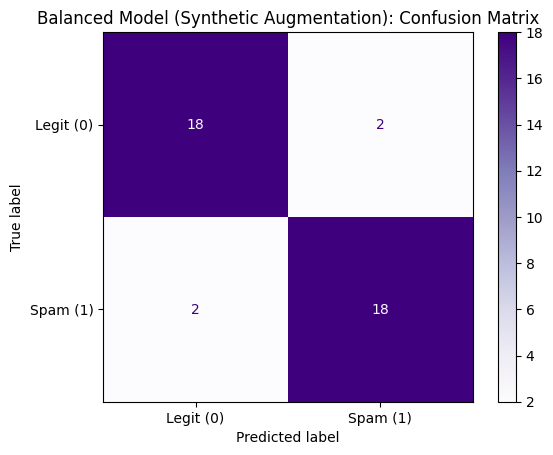

In [19]:
#Final Balanced Model (Data-Centric Fix)

#merge og data with synthetic data
balanced_df = pd.concat([df[['Combined_Text', 'Label']], synthetic_df], ignore_index=True)

print(f"New Balanced Dataset Size: {len(balanced_df)} rows")
print(f"Legit: {len(balanced_df[balanced_df['Label'] == 0])}, Spam: {len(balanced_df[balanced_df['Label'] == 1])}")

#Train/Test Split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    balanced_df['Combined_Text'], balanced_df['Label'], test_size=0.2, random_state=42, stratify=balanced_df['Label']
)

#tokenize
train_df_bal = pd.DataFrame({'text': X_train_bal.values, 'label': y_train_bal.values})
test_df_bal = pd.DataFrame({'text': X_test_bal.values, 'label': y_test_bal.values})

train_dataset_bal = Dataset.from_pandas(train_df_bal).map(tokenize_function, batched=True).remove_columns(["text"])
test_dataset_bal = Dataset.from_pandas(test_df_bal).map(tokenize_function, batched=True).remove_columns(["text"])
train_dataset_bal.set_format("torch")
test_dataset_bal.set_format("torch")

#initialize fresh baseline model
final_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

final_args = TrainingArguments(
    output_dir="./results_final",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

#go back to the standard Trainer no custom weights needed anymore
final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=train_dataset_bal,
    eval_dataset=test_dataset_bal,
    compute_metrics=compute_metrics,
)

print("\nTraining Final Balanced Model...")
final_trainer.train()

print("\nEvaluating Final Model on Test Set...")
final_results = final_trainer.evaluate()
print(f"Final Test Metrics: {final_results}")

predictions_f = final_trainer.predict(test_dataset_bal)
y_pred_f = predictions_f.predictions.argmax(-1)
y_true_f = predictions_f.label_ids

cm_f = confusion_matrix(y_true_f, y_pred_f)
disp_f = ConfusionMatrixDisplay(confusion_matrix=cm_f, display_labels=['Legit (0)', 'Spam (1)'])
disp_f.plot(cmap=plt.cm.Purples)
plt.title("Balanced Model (Synthetic Augmentation): Confusion Matrix")
plt.show()